# 1. Import pkgs

In [892]:
import numpy as np 
import pandas as pd
import os
!pip install missingno
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn import __version__ as sklearn_version
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression

# 2. Load Data

In [893]:
!cd "/Users/grace/Documents/GitHubRepos/capstone2_immunization/"
data = pd.read_csv("/Users/grace/Documents/GitHubRepos/capstone2_immunization/imm_df_cleaner.csv")

In [894]:
data.columns

Index(['county_name', '% Low Birthweight', '# Primary Care Physicians',
       'Primary Care Physicians Rate', '% Vaccinated Flu',
       '% Children in Poverty', 'Infant Mortality Rate',
       '# Uninsured Children', '% Uninsured Children', '# Food Insecure',
       '% Food Insecure', 'Segregation index_b',
       'Other Primary Care Provider Rate',
       'Other Primary Care Provider Ratio (str)', 'Median Household Income',
       '% Enrolled in Free or Reduced Lunch', 'Population', '% Female',
       '% Rural', 'year', '% Broadband Access', '% Less Than 18 Years of Age',
       'mmr_doses_0_24_months', 'mmr_doses_2_8_years', 'mmr_doses_9_17_years',
       'live_births', 'kin_DTP_cov', 'kin_HepA_cov', 'kin_HepB_cov',
       'kin_mmr_cov', 'kin_polio_cov', 'kin_varic_cov', 'Estimated hesitant',
       'Estimated hesitant or unsure', 'Estimated strongly hesitant',
       'Social Vulnerability Index (SVI)', 'SVI Category',
       'CVAC level of concern for vaccination rollout',
       

# Remove missing values
- not sure how to deal with missing values among features/covariates given i have time series data

<Axes: >

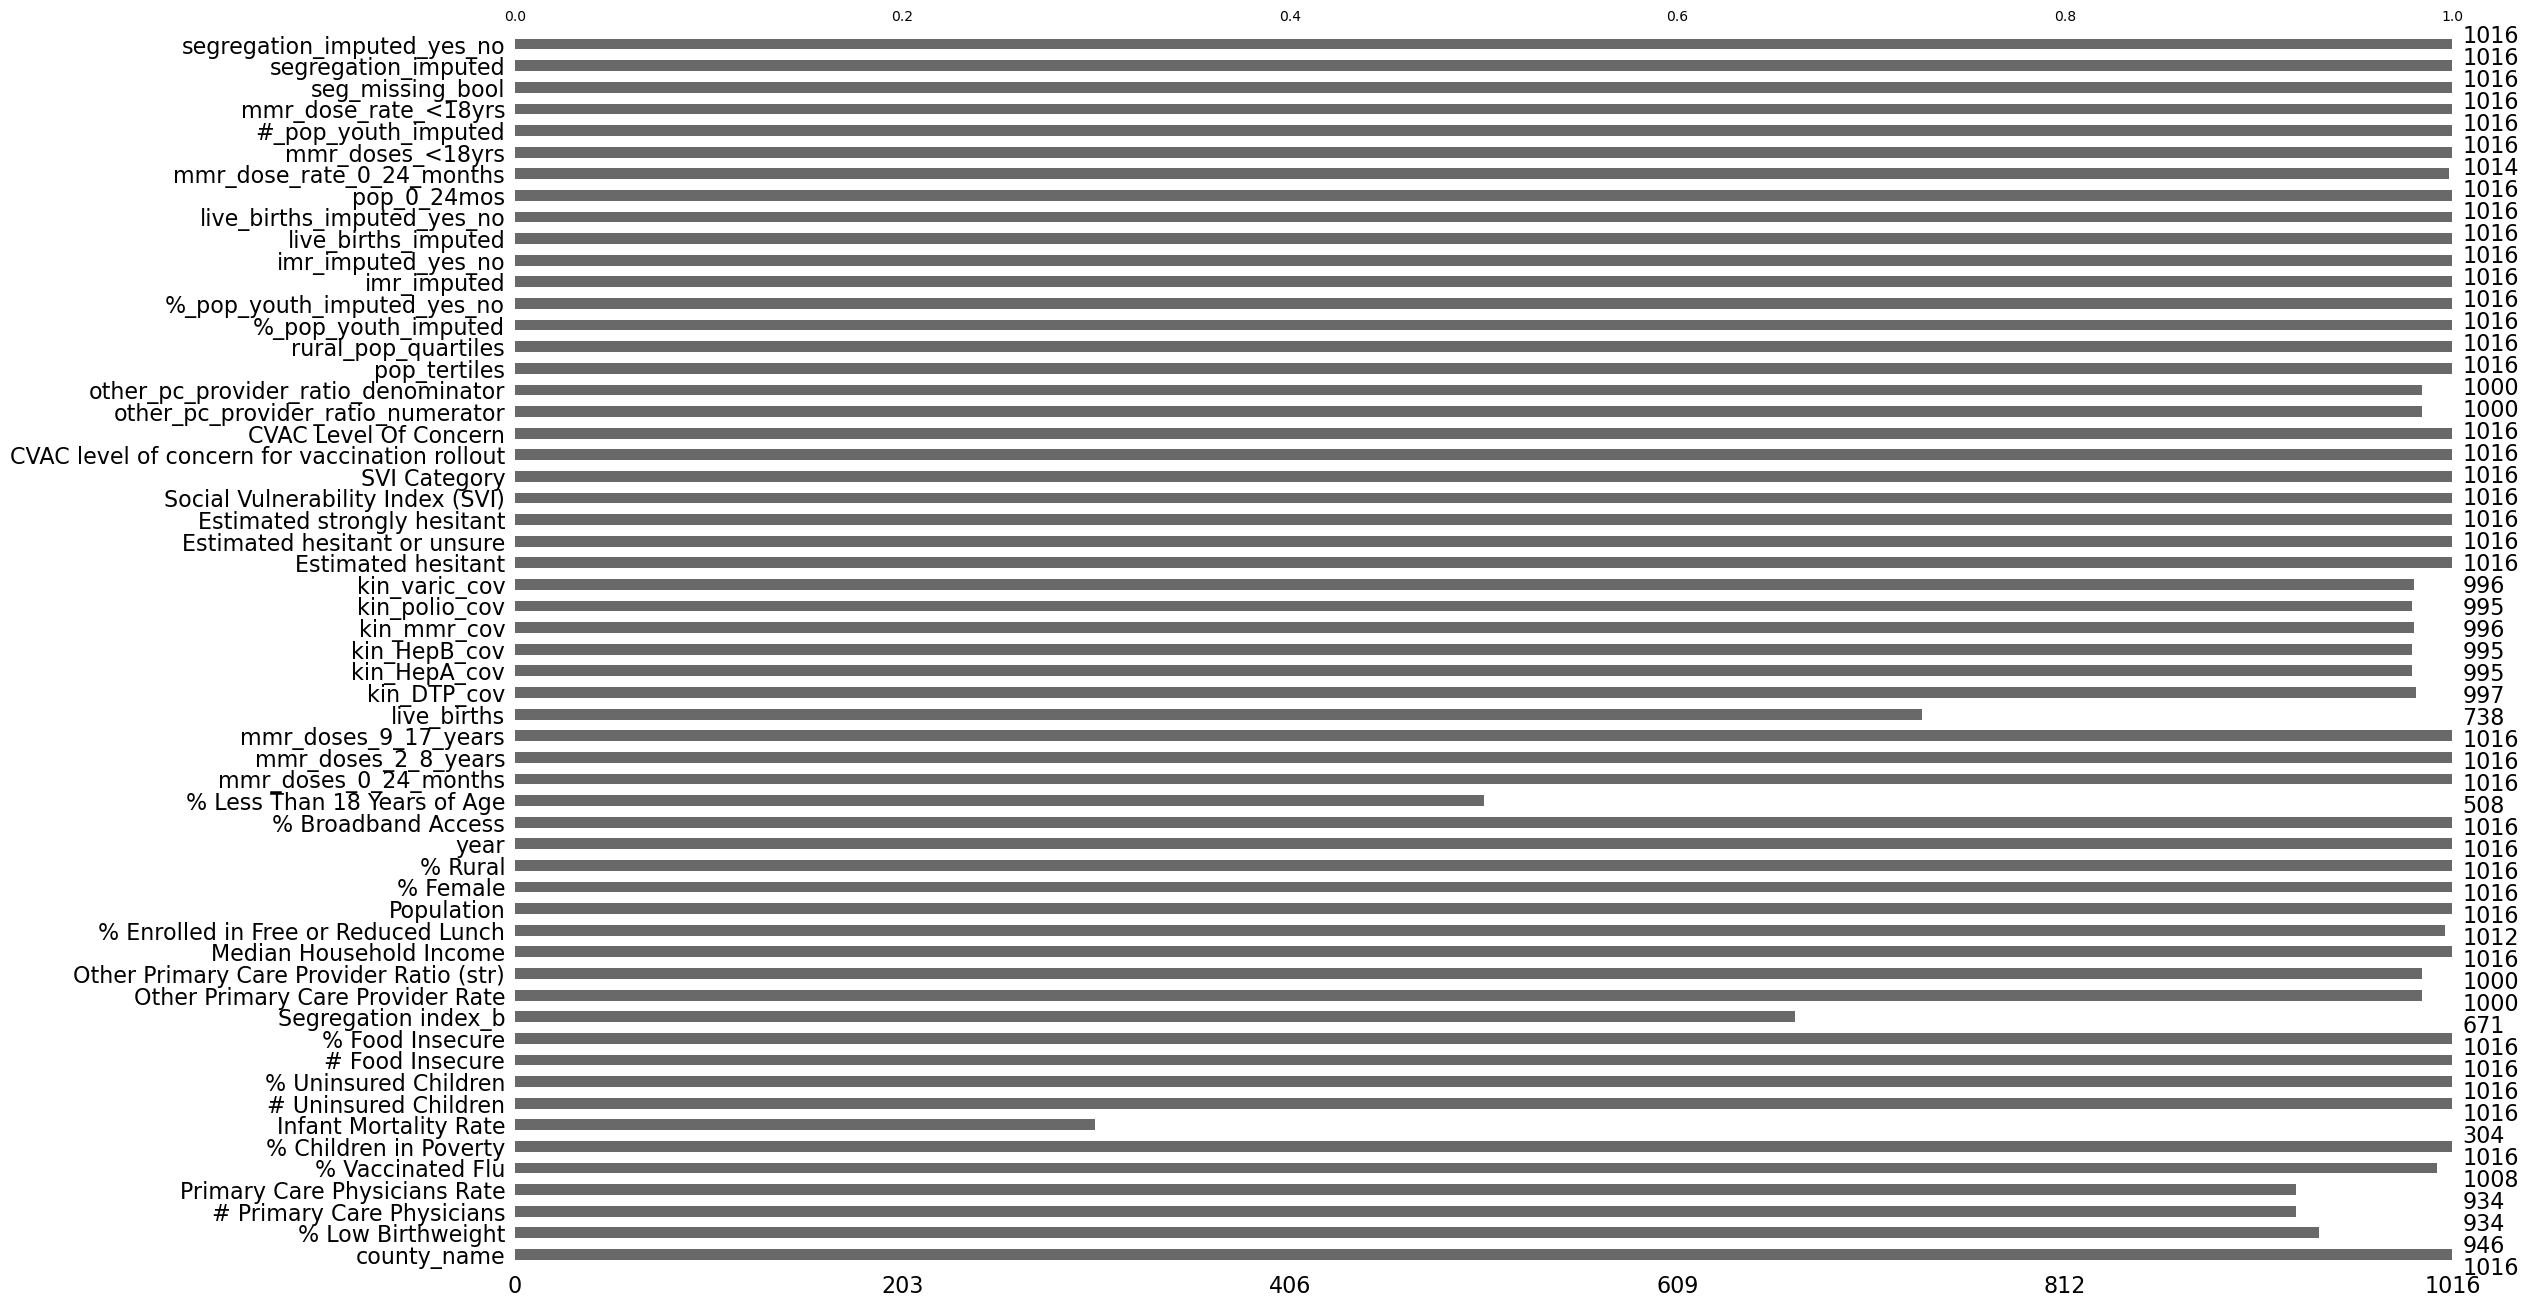

In [895]:
msno.bar(data)

In [896]:
# Remove the six counties that are missing the MMR coverage among kindergarteners since this will be our Y
missing_y = ['DeWitt', 'Loving','McMullen','McCulloch', 'McLennan','La Salle','Stonewall']
missing_y_mask = data['county_name'].isin(missing_y)
counties_missing_kin_mmr_cov = data.loc[missing_y_mask][['county_name','year','kin_mmr_cov']].sort_values(by= ['county_name','kin_mmr_cov'])
print(counties_missing_kin_mmr_cov)

type(counties_missing_kin_mmr_cov)
counties_missing_kin_mmr_cov.shape

    county_name  year  kin_mmr_cov
58       DeWitt  2020          NaN
312      DeWitt  2021          NaN
566      DeWitt  2022          NaN
820      DeWitt  2023          NaN
900    La Salle  2023     0.966102
138    La Salle  2020     0.979381
392    La Salle  2021     1.000000
646    La Salle  2022          NaN
150      Loving  2020          NaN
404      Loving  2021          NaN
658      Loving  2022          NaN
912      Loving  2023          NaN
159   McCulloch  2020     0.988095
413   McCulloch  2021          NaN
667   McCulloch  2022          NaN
921   McCulloch  2023          NaN
160    McLennan  2020     0.969383
414    McLennan  2021          NaN
668    McLennan  2022          NaN
922    McLennan  2023          NaN
161    McMullen  2020          NaN
415    McMullen  2021          NaN
669    McMullen  2022          NaN
923    McMullen  2023          NaN
978   Stonewall  2023     0.857143
470   Stonewall  2021     0.916667
724   Stonewall  2022     1.000000
216   Stonewall  202

(28, 3)

In [897]:
missing_y_idx = data.loc[missing_y_mask].index
data_test = data.loc[~data.index.isin(missing_y_idx)]
print("Shape before deleting 6 counties with missing data:", data.shape)
print("Shape after deleting 6 counties with missing data:", data_test.shape)


Shape before deleting 6 counties with missing data: (1016, 57)
Shape after deleting 6 counties with missing data: (988, 57)


In [898]:
# save most recent changes
data = data_test

Drop features/variables missing the largest proportion of data that have already been imputed 

In [899]:
missing_df = pd.DataFrame({'# Missing':data.isnull().sum(),'% Missing': round(data.isnull().sum()/len(data),2)})
print(missing_df.sort_values(by = '% Missing', ascending = False).head(20))
cols_to_drop = missing_df.loc[missing_df['% Missing']>0.25].index.to_list()

                                               # Missing  % Missing
Infant Mortality Rate                                688       0.70
% Less Than 18 Years of Age                          494       0.50
Segregation index_b                                  326       0.33
live_births                                          268       0.27
# Primary Care Physicians                             78       0.08
Primary Care Physicians Rate                          78       0.08
% Low Birthweight                                     58       0.06
Other Primary Care Provider Ratio (str)               16       0.02
other_pc_provider_ratio_denominator                   16       0.02
other_pc_provider_ratio_numerator                     16       0.02
Other Primary Care Provider Rate                      16       0.02
rural_pop_quartiles                                    0       0.00
pop_tertiles                                           0       0.00
county_name                                     

Drop the columns with more than 25% of values missing. I plan to impute those using SimpleImputer.
Also drop 'Other Primary Care Provider Ratio (str)' since that was already converted to its numeric counterpart (other_p_provider_ratio) in the previous script.

In [900]:
data_test = data.drop(columns = cols_to_drop + ['Other Primary Care Provider Ratio (str)'])
data_test.columns

Index(['county_name', '% Low Birthweight', '# Primary Care Physicians',
       'Primary Care Physicians Rate', '% Vaccinated Flu',
       '% Children in Poverty', '# Uninsured Children', '% Uninsured Children',
       '# Food Insecure', '% Food Insecure',
       'Other Primary Care Provider Rate', 'Median Household Income',
       '% Enrolled in Free or Reduced Lunch', 'Population', '% Female',
       '% Rural', 'year', '% Broadband Access', 'mmr_doses_0_24_months',
       'mmr_doses_2_8_years', 'mmr_doses_9_17_years', 'kin_DTP_cov',
       'kin_HepA_cov', 'kin_HepB_cov', 'kin_mmr_cov', 'kin_polio_cov',
       'kin_varic_cov', 'Estimated hesitant', 'Estimated hesitant or unsure',
       'Estimated strongly hesitant', 'Social Vulnerability Index (SVI)',
       'SVI Category', 'CVAC level of concern for vaccination rollout',
       'CVAC Level Of Concern', 'other_pc_provider_ratio_numerator',
       'other_pc_provider_ratio_denominator', 'pop_tertiles',
       'rural_pop_quartiles', '%_p

In [901]:
data_test.select_dtypes(include = 'object').columns

Index(['county_name', 'SVI Category', 'CVAC Level Of Concern', 'pop_tertiles',
       'rural_pop_quartiles'],
      dtype='object')

In [902]:
data_test.shape

(988, 52)

In [903]:
data = data_test

Recall that several demographic variables were imputed in the eda file in order to estimate the # of MMR doses count per child 0-23 months. However, given the limitations of that indicator, we'll aim to predict the Kindergarten MMR coverage rate going forward and not the MMR dose count rate.

# Examine MMR coverage outliers

<div style="background-color: pink;">

**Question**: should i simply remove these outliers or impute them? If I impute them, should i do so before or after train/test split.

</div>

In [904]:
low_outlier_threshold = data['kin_mmr_cov'].quantile(0.01)
low_outlier_threshold

0.809632815342238

In [905]:
low_outlier_threshold_mask = data['kin_mmr_cov'] < low_outlier_threshold
low_outliers_df = data.loc[low_outlier_threshold_mask][['county_name','kin_mmr_cov','year']].sort_values(by = ['kin_mmr_cov'], ascending = True)
print(low_outliers_df.shape)
print(low_outliers_df)

(10, 3)
      county_name  kin_mmr_cov  year
896          King     0.500000  2023
477  Throckmorton     0.631579  2021
948          Polk     0.650284  2023
654     Limestone     0.730104  2022
642          King     0.733333  2022
349          Hall     0.789474  2021
385          Kent     0.800000  2021
839         Foard     0.800000  2023
82         Gaines     0.804348  2020
336        Gaines     0.808118  2021


In [906]:
low_outliers_df.sort_values(by = ['county_name', 'kin_mmr_cov'], ascending = False)

,county_name,kin_mmr_cov,year
477,Throckmorton,0.631579,2021
948,Polk,0.650284,2023
654,Limestone,0.730104,2022
642,King,0.733333,2022
896,King,0.500000,2023
385,Kent,0.800000,2021
349,Hall,0.789474,2021
336,Gaines,0.808118,2021
82,Gaines,0.804348,2020
839,Foard,0.800000,2023


In [907]:
low_outliers_df.groupby(['county_name'])['kin_mmr_cov'].median().sort_values(ascending = True)

county_name
King            0.616667
Throckmorton    0.631579
Polk            0.650284
Limestone       0.730104
Hall            0.789474
Foard           0.800000
Kent            0.800000
Gaines          0.806233
Name: kin_mmr_cov, dtype: float64

I'm guessing many of these counties just had unusual reporting circumstances or poor data that year which led to the outliers.
Especially Throckmorton and Polk for those particular years. Check to see what values those counties had for other years where their MMR coverage was not a low outlier.

In [908]:
low_counties_list = low_outliers_df.iloc[:,0].to_list()
data.loc[data['county_name'].isin(low_counties_list),['county_name','year','kin_mmr_cov']].sort_values(by = ['county_name','year'], ascending = False)
#data.loc[data['county_name'].isin(low_counties_list), ['county_name', 'year', 'kin_mmr_cov']]


,county_name,year,kin_mmr_cov
985,Throckmorton,2023,0.857143
731,Throckmorton,2022,0.954545
477,Throckmorton,2021,0.631579
223,Throckmorton,2020,1.000000
948,Polk,2023,0.650284
694,Polk,2022,0.969424
440,Polk,2021,0.963710
186,Polk,2020,0.946108
908,Limestone,2023,0.809859
654,Limestone,2022,0.730104


For at least Throckmorton and King counties, the outlying value is so much lower than the preceding year or the preceding and following year, they probably reflect data quality issues and not real variations in coverage. Based on this, keep most of these values and impute only those in the lowest 0.5% of data set 

In [909]:
lower_outlier_threshold = data['kin_mmr_cov'].quantile(0.005)
lower_outlier_threshold
lower_outlier_threshold_mask = data['kin_mmr_cov']< data['kin_mmr_cov'].quantile(0.005)

In [910]:
# compare the distributions with and without the coverage outliers removed

trimmed_data = data.copy()
trimmed_data.loc[trimmed_data['kin_mmr_cov'] < lower_outlier_threshold, 'kin_mmr_cov'] = pd.NA

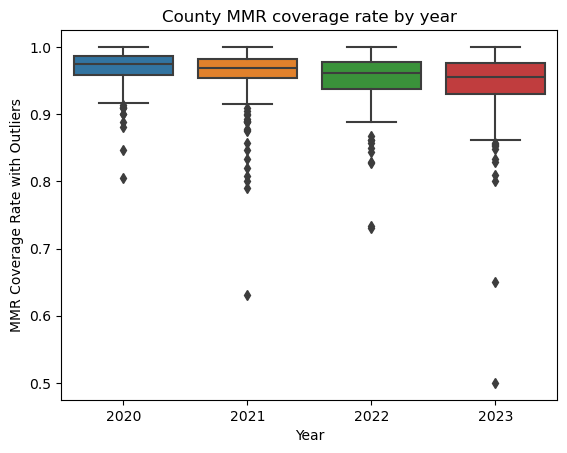

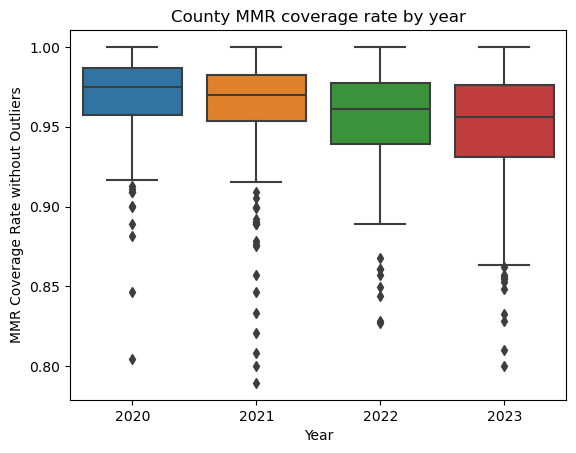

In [911]:

# Make box plot of by year
_ = sns.boxplot(x = 'year', y = 'kin_mmr_cov', data = data)
# Label the axes
_ = plt.xlabel('Year')
_ = plt.ylabel('MMR Coverage Rate with Outliers')
_ = plt.title('County MMR coverage rate by year')
# Show the plot
plt.show()

# Make box plot of by year
_ = sns.boxplot(x = 'year', y = 'kin_mmr_cov', data = trimmed_data)
# Label the axes
_ = plt.xlabel('Year')
_ = plt.ylabel('MMR Coverage Rate without Outliers')
_ = plt.title('County MMR coverage rate by year')
# Show the plot
plt.show()

Make sure lower outliers were set to null

# FIX 
The code in the reminder of this section appears TWICE (once here and once after the train/test split)

In [912]:
trimmed_data.loc[lower_outlier_threshold_mask][['county_name','kin_mmr_cov','year']].sort_values(by = ['kin_mmr_cov'], ascending = True)

,county_name,kin_mmr_cov,year
477,Throckmorton,NaN,2021
642,King,NaN,2022
654,Limestone,NaN,2022
896,King,NaN,2023
948,Polk,NaN,2023


In [913]:
#Save new version of data set with imputed coverage values and without the original ones
# data = trimmed_data

Impute the coverage for a small set of outliers. I ended up not using a simpleImputer because I wanted to apply the medians by country such that a county's imputed value was based only on its own values for other years, not on the values in other counties. The code seemed more straightforward imputing these manually vs using the SimpleImputer object.

Will this causes issues if I move this step after my train-test split?

In [914]:
# imputer = SimpleImputer(strategy = 'median', add_indicator = True)

In [915]:
# create a varible that identifies rows witih imputed MMR coverage values (before imputation)
#data['kin_mmr_cov_imputed_yes_no'] = data['kin_mmr_cov'].isna()

In [916]:
#data['kin_mmr_cov_imputed'] = (
#    data.groupby('county_name')['kin_mmr_cov']
#        .transform(lambda x: x.fillna(x.median())) # fill in missings with median
#)

In [917]:
# check to make sure imputation was sucessful
# data.loc[lower_outlier_threshold_mask, ['county_name', 'year','kin_mmr_cov','kin_mmr_cov_imputed','kin_mmr_cov_imputed_yes_no']]

In [918]:
# drop original kin_mmr_cov variable
print(data.shape)
#data.drop('kin_mmr_cov',axis =1, inplace=True)
print(data.shape)

(988, 52)
(988, 52)


Outliers have been successfully imputed and saved in kin_mmr_cov_imputed

# Change Data Types (to numeric and bool)

In [919]:
data.dtypes

county_name                                       object
% Low Birthweight                                float64
# Primary Care Physicians                        float64
Primary Care Physicians Rate                     float64
% Vaccinated Flu                                 float64
% Children in Poverty                            float64
# Uninsured Children                               int64
% Uninsured Children                             float64
# Food Insecure                                    int64
% Food Insecure                                  float64
Other Primary Care Provider Rate                 float64
Median Household Income                            int64
% Enrolled in Free or Reduced Lunch              float64
Population                                         int64
% Female                                         float64
% Rural                                          float64
year                                               int64
% Broadband Access             

In [920]:
# columns_ending_with_yes_no 
boolean_columns = [col for col in data.columns if col.endswith('yes_no')] + ['seg_missing_bool']
print("Dichotomous feature data types:, ", [print(col, data[col].dtype) for col in boolean_columns])
# [data[col].unique() for col in columns_ending_with_yes_no]
#print(columns_ending_with_yes_no.dtype)

%_pop_youth_imputed_yes_no float64
imr_imputed_yes_no float64
live_births_imputed_yes_no float64
segregation_imputed_yes_no float64
seg_missing_bool bool
Dichotomous feature data types:,  [None, None, None, None, None]


In [921]:
# convert all dichotomous features to integer data type
for col in boolean_columns:
    data[col] = data[col].astype('bool')
    print(data[col].dtype)
#data['seg_missing_bool']= data['seg_missing_bool'].astype('int')
#print(type(data[['kin_mmr_cov_imputed_yes_no','seg_missing_bool']]))
#print([data[col].unique() for col in boolean_columns])

bool
bool
bool
bool
bool


In [922]:
data.dtypes

county_name                                       object
% Low Birthweight                                float64
# Primary Care Physicians                        float64
Primary Care Physicians Rate                     float64
% Vaccinated Flu                                 float64
% Children in Poverty                            float64
# Uninsured Children                               int64
% Uninsured Children                             float64
# Food Insecure                                    int64
% Food Insecure                                  float64
Other Primary Care Provider Rate                 float64
Median Household Income                            int64
% Enrolled in Free or Reduced Lunch              float64
Population                                         int64
% Female                                         float64
% Rural                                          float64
year                                               int64
% Broadband Access             

In [923]:
# remove 'county_name' column, make it the df's index
data_test.index = data_test['county_name']
data_test = data_test.drop('county_name', axis =1)

In [924]:
data_test.columns

Index(['% Low Birthweight', '# Primary Care Physicians',
       'Primary Care Physicians Rate', '% Vaccinated Flu',
       '% Children in Poverty', '# Uninsured Children', '% Uninsured Children',
       '# Food Insecure', '% Food Insecure',
       'Other Primary Care Provider Rate', 'Median Household Income',
       '% Enrolled in Free or Reduced Lunch', 'Population', '% Female',
       '% Rural', 'year', '% Broadband Access', 'mmr_doses_0_24_months',
       'mmr_doses_2_8_years', 'mmr_doses_9_17_years', 'kin_DTP_cov',
       'kin_HepA_cov', 'kin_HepB_cov', 'kin_mmr_cov', 'kin_polio_cov',
       'kin_varic_cov', 'Estimated hesitant', 'Estimated hesitant or unsure',
       'Estimated strongly hesitant', 'Social Vulnerability Index (SVI)',
       'SVI Category', 'CVAC level of concern for vaccination rollout',
       'CVAC Level Of Concern', 'other_pc_provider_ratio_numerator',
       'other_pc_provider_ratio_denominator', 'pop_tertiles',
       'rural_pop_quartiles', '%_pop_youth_impute

In [925]:
data_test.index

Index(['Anderson', 'Andrews', 'Angelina', 'Aransas', 'Archer', 'Armstrong',
       'Atascosa', 'Austin', 'Bailey', 'Bandera',
       ...
       'Willacy', 'Williamson', 'Wilson', 'Winkler', 'Wise', 'Wood', 'Yoakum',
       'Young', 'Zapata', 'Zavala'],
      dtype='object', name='county_name', length=988)

In [926]:
# save changes
data=data_test

# Create Dummy variables

One-hot encoded remaining string variables in the data
- not that both categorical variables already exist in numeric form:
- 'CVAC Level Of Concern' is the categorical binned form of 'CVAC level of concern for vaccination rollout'
- 'SVI Category' is the categorical binned form of 'Social Vulnerability Index (SVI)'

In [927]:
print(data['CVAC Level Of Concern'].unique())
data['SVI Category'].unique()

['Very High Concern' 'Moderate Concern' 'High Concern']


array(['High Vulnerability', 'Moderate Vulnerability',
       'Very High Vulnerability', 'Very Low Vulnerability',
       'Low Vulnerability'], dtype=object)

In [928]:
data_test.select_dtypes(include = 'object').columns

Index(['SVI Category', 'CVAC Level Of Concern', 'pop_tertiles',
       'rural_pop_quartiles'],
      dtype='object')

Population tertiles and the % Rural population in a county are two variables that aren't critical, I made them in the last script. But I will hot-encode them in case they model better than the numeric versions.

In [929]:
data_test = pd.get_dummies(data, columns = ['SVI Category', 'CVAC Level Of Concern','rural_pop_quartiles','pop_tertiles'], drop_first=True, prefix = 'OH_')
#one_hot_encoded.columns.startswith(
print([col for col in data_test.columns if col.startswith('OH_')])
print(data_test.shape)
data = data_test

['OH__Low Vulnerability', 'OH__Moderate Vulnerability', 'OH__Very High Vulnerability', 'OH__Very Low Vulnerability', 'OH__Moderate Concern', 'OH__Very High Concern', 'OH__urban', 'OH__very rural', 'OH__very urban', 'OH__medium', 'OH__small']
(988, 58)


In [930]:
data_test.select_dtypes(include = 'object').columns

Index([], dtype='object')

In [931]:
print(data_test.shape)
print(data_test.head(1))

(988, 58)
             % Low Birthweight  # Primary Care Physicians  \
county_name                                                 
Anderson              7.307041                       20.0   

             Primary Care Physicians Rate  % Vaccinated Flu  \
county_name                                                   
Anderson                         34.63743              43.0   

             % Children in Poverty  # Uninsured Children  \
county_name                                                
Anderson                      22.6                  1385   

             % Uninsured Children  # Food Insecure  % Food Insecure  \
county_name                                                           
Anderson                11.824469            10520             18.2   

             Other Primary Care Provider Rate  ...  \
county_name                                    ...   
Anderson                              53.3958  ...   

             OH__Moderate Vulnerability  OH__Very High Vul

In [932]:
data = data_test

# Train Test Split

In [933]:
X_train, X_test, y_train, y_test = train_test_split(data.drop(columns='kin_mmr_cov'), 
                                                    data.kin_mmr_cov, test_size=0.25, 
                                                    random_state=1)

In [934]:
print(y_train.shape, y_test.shape)
print(print(y_train.head(), y_test.head()))

(741,) (247,)
county_name
Mason          0.960000
Hill           0.930716
Hill           0.944215
Shackelford    0.926829
Coryell        0.972121
Name: kin_mmr_cov, dtype: float64 county_name
Gonzales     0.975000
Wilbarger    0.986111
Wood         0.941176
Potter       0.968666
Oldham       0.970588
Name: kin_mmr_cov, dtype: float64
None


In [935]:
print(X_train.shape, X_test.shape)


(741, 57) (247, 57)


In [936]:
X_train.dtypes

% Low Birthweight                                float64
# Primary Care Physicians                        float64
Primary Care Physicians Rate                     float64
% Vaccinated Flu                                 float64
% Children in Poverty                            float64
# Uninsured Children                               int64
% Uninsured Children                             float64
# Food Insecure                                    int64
% Food Insecure                                  float64
Other Primary Care Provider Rate                 float64
Median Household Income                            int64
% Enrolled in Free or Reduced Lunch              float64
Population                                         int64
% Female                                         float64
% Rural                                          float64
year                                               int64
% Broadband Access                               float64
mmr_doses_0_24_months          

In [937]:
print(y_train.dtypes)
len(y_train)

float64


741

In [938]:
X_test.dtypes

% Low Birthweight                                float64
# Primary Care Physicians                        float64
Primary Care Physicians Rate                     float64
% Vaccinated Flu                                 float64
% Children in Poverty                            float64
# Uninsured Children                               int64
% Uninsured Children                             float64
# Food Insecure                                    int64
% Food Insecure                                  float64
Other Primary Care Provider Rate                 float64
Median Household Income                            int64
% Enrolled in Free or Reduced Lunch              float64
Population                                         int64
% Female                                         float64
% Rural                                          float64
year                                               int64
% Broadband Access                               float64
mmr_doses_0_24_months          

In [939]:
# calculate the average MMR coverage in the test set
print("Mean MMR coverage in training data:", round(y_train.mean(),5), "\nMean MMR coverage in test data:", round(y_train.mean(),5))

Mean MMR coverage in training data: 0.95792 
Mean MMR coverage in test data: 0.95792


# Standardize scales

- Consider using log transformation (PowerTransformer) on kindergarten coverage variables and the population since those distributions are highly skewed.
- standardization for other variables. Using min/max Scaler probably not appropriate since while in theory coverage rates can't be over 100%, this is often not the case due to data quality issues. But in this data set kin_mmr_cov (kindergarten MMR coverage rate is bounded by 100%, **so would i potentially apply this to my Y? to all variables?**

In [940]:
data.dtypes

% Low Birthweight                                float64
# Primary Care Physicians                        float64
Primary Care Physicians Rate                     float64
% Vaccinated Flu                                 float64
% Children in Poverty                            float64
# Uninsured Children                               int64
% Uninsured Children                             float64
# Food Insecure                                    int64
% Food Insecure                                  float64
Other Primary Care Provider Rate                 float64
Median Household Income                            int64
% Enrolled in Free or Reduced Lunch              float64
Population                                         int64
% Female                                         float64
% Rural                                          float64
year                                               int64
% Broadband Access                               float64
mmr_doses_0_24_months          

Split data into numeric vs. boolean features before standardization since only numeric features need to be standardized

In [941]:
numeric_cols = data.select_dtypes(include = ['int','float']).columns.to_list()
print(len(numeric_cols))
numeric_cols

42


['% Low Birthweight',
 '# Primary Care Physicians',
 'Primary Care Physicians Rate',
 '% Vaccinated Flu',
 '% Children in Poverty',
 '# Uninsured Children',
 '% Uninsured Children',
 '# Food Insecure',
 '% Food Insecure',
 'Other Primary Care Provider Rate',
 'Median Household Income',
 '% Enrolled in Free or Reduced Lunch',
 'Population',
 '% Female',
 '% Rural',
 'year',
 '% Broadband Access',
 'mmr_doses_0_24_months',
 'mmr_doses_2_8_years',
 'mmr_doses_9_17_years',
 'kin_DTP_cov',
 'kin_HepA_cov',
 'kin_HepB_cov',
 'kin_mmr_cov',
 'kin_polio_cov',
 'kin_varic_cov',
 'Estimated hesitant',
 'Estimated hesitant or unsure',
 'Estimated strongly hesitant',
 'Social Vulnerability Index (SVI)',
 'CVAC level of concern for vaccination rollout',
 'other_pc_provider_ratio_numerator',
 'other_pc_provider_ratio_denominator',
 '%_pop_youth_imputed',
 'imr_imputed',
 'live_births_imputed',
 'pop_0_24mos',
 'mmr_dose_rate_0_24_months',
 'mmr_doses_<18yrs',
 '#_pop_youth_imputed',
 'mmr_dose_rate_

In [942]:
not_numeric_cols = data.select_dtypes(include = ['bool']).columns.to_list()
print(not_numeric_cols)
data_not_numeric = data[not_numeric_cols]

['%_pop_youth_imputed_yes_no', 'imr_imputed_yes_no', 'live_births_imputed_yes_no', 'seg_missing_bool', 'segregation_imputed_yes_no', 'OH__Low Vulnerability', 'OH__Moderate Vulnerability', 'OH__Very High Vulnerability', 'OH__Very Low Vulnerability', 'OH__Moderate Concern', 'OH__Very High Concern', 'OH__urban', 'OH__very rural', 'OH__very urban', 'OH__medium', 'OH__small']


Scale the numeric columns

In [943]:
scaler = StandardScaler()
scaled_array = scaler.fit_transform(data[numeric_cols])
scaled_df = pd.DataFrame(scaled_array, columns=numeric_cols, index=data.index)
scaled_df.head()

,% Low Birthweight,# Primary Care Physicians,Primary Care Physicians Rate,% Vaccinated Flu,% Children in Poverty,# Uninsured Children,% Uninsured Children,# Food Insecure,% Food Insecure,Other Primary Care Provider Rate,...,other_pc_provider_ratio_denominator,%_pop_youth_imputed,imr_imputed,live_births_imputed,pop_0_24mos,mmr_dose_rate_0_24_months,mmr_doses_<18yrs,#_pop_youth_imputed,mmr_dose_rate_<18yrs,segregation_imputed
county_name,,,,,,,,,,,,,,,,,,,,,
Anderson,-0.608164,-0.202420,-0.234229,0.495547,0.018818,-0.157769,-0.562319,-0.094901,1.080652,-0.297980,...,0.230408,-0.044755,-0.017149,-0.133963,-0.134030,-0.124615,-0.185750,-0.145461,-0.757399,-0.543572
Andrews,-1.420557,-0.241861,0.369622,-1.430195,-1.119235,-0.201047,-0.016250,-0.248772,-2.187599,0.035214,...,0.230408,-0.044755,-0.017149,-0.186791,-0.186856,-0.088076,-0.198493,-0.236722,1.309499,-1.297007
Angelina,0.787892,-0.087684,0.685174,1.002321,0.561379,-0.054342,-0.520960,0.008077,1.314099,0.344519,...,0.230408,-0.044755,-0.036215,-0.005196,-0.005264,-0.123980,-0.084074,-0.079100,-0.160641,-0.162147
Aransas,0.958872,-0.241861,-0.213387,0.394192,1.620034,-0.212123,-0.260929,-0.204177,0.513711,-0.484404,...,0.230408,-0.044755,-0.017149,-0.210728,-0.210793,-0.101341,-0.230457,-0.223776,-0.622800,1.409094
Archer,-0.070973,NaN,NaN,0.799611,-1.079536,-0.237503,0.140354,-0.253028,-0.320027,NaN,...,NaN,-0.044755,-0.017149,-0.231777,-0.231840,-0.046812,-0.248286,-0.258073,-0.062566,-0.012149


In [944]:
data_test= pd.concat([scaled_df, data_not_numeric], axis=1)
data_test.shape

(988, 58)

In [945]:
data=data_test

# Imputate MMR coverage outliers

Question: If I'm deleting and imputing outliers in the training data set based on county/year groupings, 
how do i make impute only country/years desired if all i have is a y_train array without the county/years??? 

Impute MMR coverage outliers on y_training data by removing lowest 1% of data

In [946]:
p1_outlier_threshold = data['kin_mmr_cov'].quantile(0.01)
p1_outlier_threshold

-3.611734967408546

In [947]:
# trimmed_data.loc[p1_outlier_threshold][['kin_mmr_cov','year']].sort_values(by = ['kin_mmr_cov'], ascending = True)

In [948]:
#Save new version of data set with imputed coverage values and without the original ones
# data = trimmed_data

Impute the coverage for a small set of outliers. I ended up not using a simpleImputer because I wanted to apply the medians by country such that a county's imputed value was based only on its own values for other years, not on the values in other counties. The code seemed more straightforward imputing these manually vs using the SimpleImputer object.

Will this causes issues if I move this step after my train-test split?

In [949]:
# imputer = SimpleImputer(strategy = 'median', add_indicator = True)

In [950]:
# create a varible that identifies rows witih imputed MMR coverage values (before imputation)
#data['kin_mmr_cov_imputed_yes_no'] = data['kin_mmr_cov'].isna()

In [951]:
#data['kin_mmr_cov_imputed'] = (
#    data.groupby('county_name')['kin_mmr_cov']
#        .transform(lambda x: x.fillna(x.median())) # fill in missings with median
#)

In [952]:
# check to make sure imputation was sucessful
# data.loc[lower_outlier_threshold_mask, ['county_name', 'year','kin_mmr_cov','kin_mmr_cov_imputed','kin_mmr_cov_imputed_yes_no']]

In [953]:
# drop original kin_mmr_cov variable
print(data.shape)
#data.drop('kin_mmr_cov',axis =1, inplace=True)
print(data.shape)

(988, 58)
(988, 58)


Outliers have been successfully imputed and saved in kin_mmr_cov_imputed

# Save processed data

In [959]:
!cd '/Users/grace/Documents/GitHubRepos/capstone2_immunization/'
# save the data to a new csv file
data.to_csv('imm_df_processed.csv', index=False) # don't save index as separate column

next steps: 

build pipeline that imputes coverage data (maybe?)

how do i translate research questions into model selection??